In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

print("All imports successful")

All imports successful


In [2]:
# Load INSEE monthly price data
# Separator is semicolon, encoding is latin-1 (French government files)
insee = pd.read_csv(
    '../data/raw/valeurs_mensuelles.csv',
    sep=';',
    encoding='latin-1'
)

print(f"Shape: {insee.shape}")
print(f"\nColumn names:")
print(insee.columns.tolist()[:10])  # first 10 columns
print(f"\nFirst 3 rows:")
insee.head(3)

Shape: (2448, 436)

Column names:
['LibellÃ©', 'idBank', 'DerniÃ¨re mise Ã\xa0 jour', 'PÃ©riode', '1990-01', '1990-02', '1990-03', '1990-04', '1990-05', '1990-06']

First 3 rows:


,LibellÃ©,idBank,DerniÃ¨re mise Ã jour,PÃ©riode,1990-01,1990-02,1990-03,1990-04,1990-05,1990-06,1990-07,1990-08,1990-09,1990-10,1990-11,1990-12,1991-01,1991-02,1991-03,1991-04,1991-05,1991-06,1991-07,1991-08,1991-09,...,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,Indice des prix Ã la consommation - Base 2015...,1763510.0,13/04/2016 00:00,NaN,82.9,83.17,83.75,84.18,84.36,84.7,84.71,84.78,85.02,85.35,85.56,85.76,85.8,85.93,86.03,86.2,86.05,86.33,86.44,86.51,86.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Codes,NaN,NaN,NaN,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indice des prix Ã la consommation - Base 2015...,1763511.0,13/04/2016 00:00,NaN,82.9,83.17,83.75,84.18,84.36,84.7,84.71,84.78,85.02,85.35,85.56,85.76,85.8,85.93,86.03,86.2,86.05,86.33,86.44,86.51,86.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Reload with correct encoding
insee = pd.read_csv(
    '../data/raw/valeurs_mensuelles.csv',
    sep=';',
    encoding='utf-8',
    on_bad_lines='skip'
)

print(f"Shape: {insee.shape}")
print(f"\nFirst column name: {insee.columns[0]}")
print(f"\nSample series labels:")
print(insee.iloc[:, 0].head(20).tolist())

Shape: (2448, 436)

First column name: Libellé

Sample series labels:
["Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Nomenclature Coicop : 03.1.1 - Tissus pour l'habillement - Série arrêtée", 'Codes', "Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Nomenclature Coicop : 03.1.1.0 - Tissus pour l'habillement - Série arrêtée", 'Codes', "Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Nomenclature Coicop : 04.3.2.9 - Autres services d'entretien et de réparation du logement - Série arrêtée", 'Codes', 'Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Nomenclature Coicop : 05.3.1.9 - Autres gros appareils ménagers - Série arrêtée', 'Codes', "Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Nomenclature Coicop : 09.1.2.3 - Instruments d'optique - Série arrêtée", 'Codes', "Indice des prix à la consommation - Base 2015 - Ensemble des mé

In [4]:
# Filter only food series (COICOP 01.x) for Metropolitan France
food_mask = (
    insee['Libellé'].str.contains('01\.', regex=True, na=False) &
    insee['Libellé'].str.contains('France métropolitaine', na=False) &
    ~insee['Libellé'].str.contains('Codes', na=False)
)

insee_food = insee[food_mask].copy()

print(f"Total series in file: {len(insee)}")
print(f"Food series (Metropolitan France): {len(insee_food)}")
print(f"\nAll food series found:")
for label in insee_food['Libellé'].tolist():
    print(' -', label)

Total series in file: 2448
Food series (Metropolitan France): 73

All food series found:
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1 - Produits alimentaires
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1.1 - Pain et céréales
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1.1.1 - Riz
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1.1.2 - Farines et autres céréales
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1.1.3 - Pain
 - Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France métropolitaine - Nomenclature Coicop : 01.1.1.4 - Autres produits de boulangerie
 - Indice des prix à la c

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\kaurn\AppData\Local\Temp\ipykernel_21260\2243980475.py:3: SyntaxWarning: invalid escape sequence '\.'
  insee['Libellé'].str.contains('01\.', regex=True, na=False) &


In [5]:
# Fix the escape sequence warning + map categories
category_map = {
    '01.1.1.6': 'Pasta & Couscous',
    '01.1.1.3': 'Bread',
    '01.1.1.4': 'Bakery & Pastry',
    '01.1.1.5': 'Prepared Meals (cereal-based)',
    '01.1.2.7': 'Charcuterie',
    '01.1.2.8': 'Processed Meat',
    '01.1.4.1': 'Butter',
    '01.1.4.2': 'Milk',
    '01.1.4.3': 'Cheese',
    '01.1.4.4': 'Eggs',
    '01.1.6':   'Fruit',
    '01.1.7':   'Vegetables',
    '01.1.8.2': 'Chocolate & Confectionery',
    '01.1.9':   'Other Food (sauces, condiments)',
    '01.2.1':   'Coffee & Tea',
    '01.2.2.2': 'Soft Drinks',
    '01.2.2.3': 'Fruit Juice',
}

# Extract COICOP code from label
insee_food['coicop_code'] = insee_food['Libellé'].str.extract(
    r'Coicop\s*:\s*([\d\.]+)'
)

# Keep only our mapped categories
insee_mapped = insee_food[
    insee_food['coicop_code'].isin(category_map.keys())
].copy()

insee_mapped['category'] = insee_mapped['coicop_code'].map(category_map)

print(f"Categories matched: {len(insee_mapped)}")
print(insee_mapped[['category', 'coicop_code']].to_string())

Categories matched: 17
                             category coicop_code
1342                            Bread    01.1.1.3
1344                  Bakery & Pastry    01.1.1.4
1346    Prepared Meals (cereal-based)    01.1.1.5
1348                 Pasta & Couscous    01.1.1.6
1368                      Charcuterie    01.1.2.7
1370                   Processed Meat    01.1.2.8
1388                           Butter    01.1.4.1
1390                             Milk    01.1.4.2
1392                           Cheese    01.1.4.3
1394                             Eggs    01.1.4.4
1412                            Fruit      01.1.6
1422                       Vegetables      01.1.7
1440        Chocolate & Confectionery    01.1.8.2
1450  Other Food (sauces, condiments)      01.1.9
1464                     Coffee & Tea      01.2.1
1476                      Soft Drinks    01.2.2.2
1478                      Fruit Juice    01.2.2.3


In [6]:
# Get date columns only (format: YYYY-MM)
date_cols = [col for col in insee_mapped.columns 
             if col[:2] in ['19', '20'] and '-' in col]

# Reshape wide to long
insee_long = insee_mapped.melt(
    id_vars=['category', 'coicop_code'],
    value_vars=date_cols,
    var_name='date',
    value_name='price_index'
)

# Clean up
insee_long['date'] = pd.to_datetime(insee_long['date'], format='%Y-%m')
insee_long['price_index'] = pd.to_numeric(insee_long['price_index'], errors='coerce')

# Filter 2015 onwards only
insee_long = insee_long[insee_long['date'] >= '2015-01-01'].copy()

# Sort
insee_long = insee_long.sort_values(['category', 'date']).reset_index(drop=True)

print(f"Shape: {insee_long.shape}")
print(f"Date range: {insee_long['date'].min()} to {insee_long['date'].max()}")
print(f"\nSample:")
print(insee_long[insee_long['category'] == 'Pasta & Couscous'].tail(10).to_string())

Shape: (2244, 4)
Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00

Sample:
              category coicop_code       date  price_index
1706  Pasta & Couscous    01.1.1.6 2025-03-01       130.71
1707  Pasta & Couscous    01.1.1.6 2025-04-01       130.21
1708  Pasta & Couscous    01.1.1.6 2025-05-01       129.49
1709  Pasta & Couscous    01.1.1.6 2025-06-01       129.25
1710  Pasta & Couscous    01.1.1.6 2025-07-01       128.78
1711  Pasta & Couscous    01.1.1.6 2025-08-01       128.40
1712  Pasta & Couscous    01.1.1.6 2025-09-01       127.89
1713  Pasta & Couscous    01.1.1.6 2025-10-01       127.41
1714  Pasta & Couscous    01.1.1.6 2025-11-01       127.43
1715  Pasta & Couscous    01.1.1.6 2025-12-01       127.45


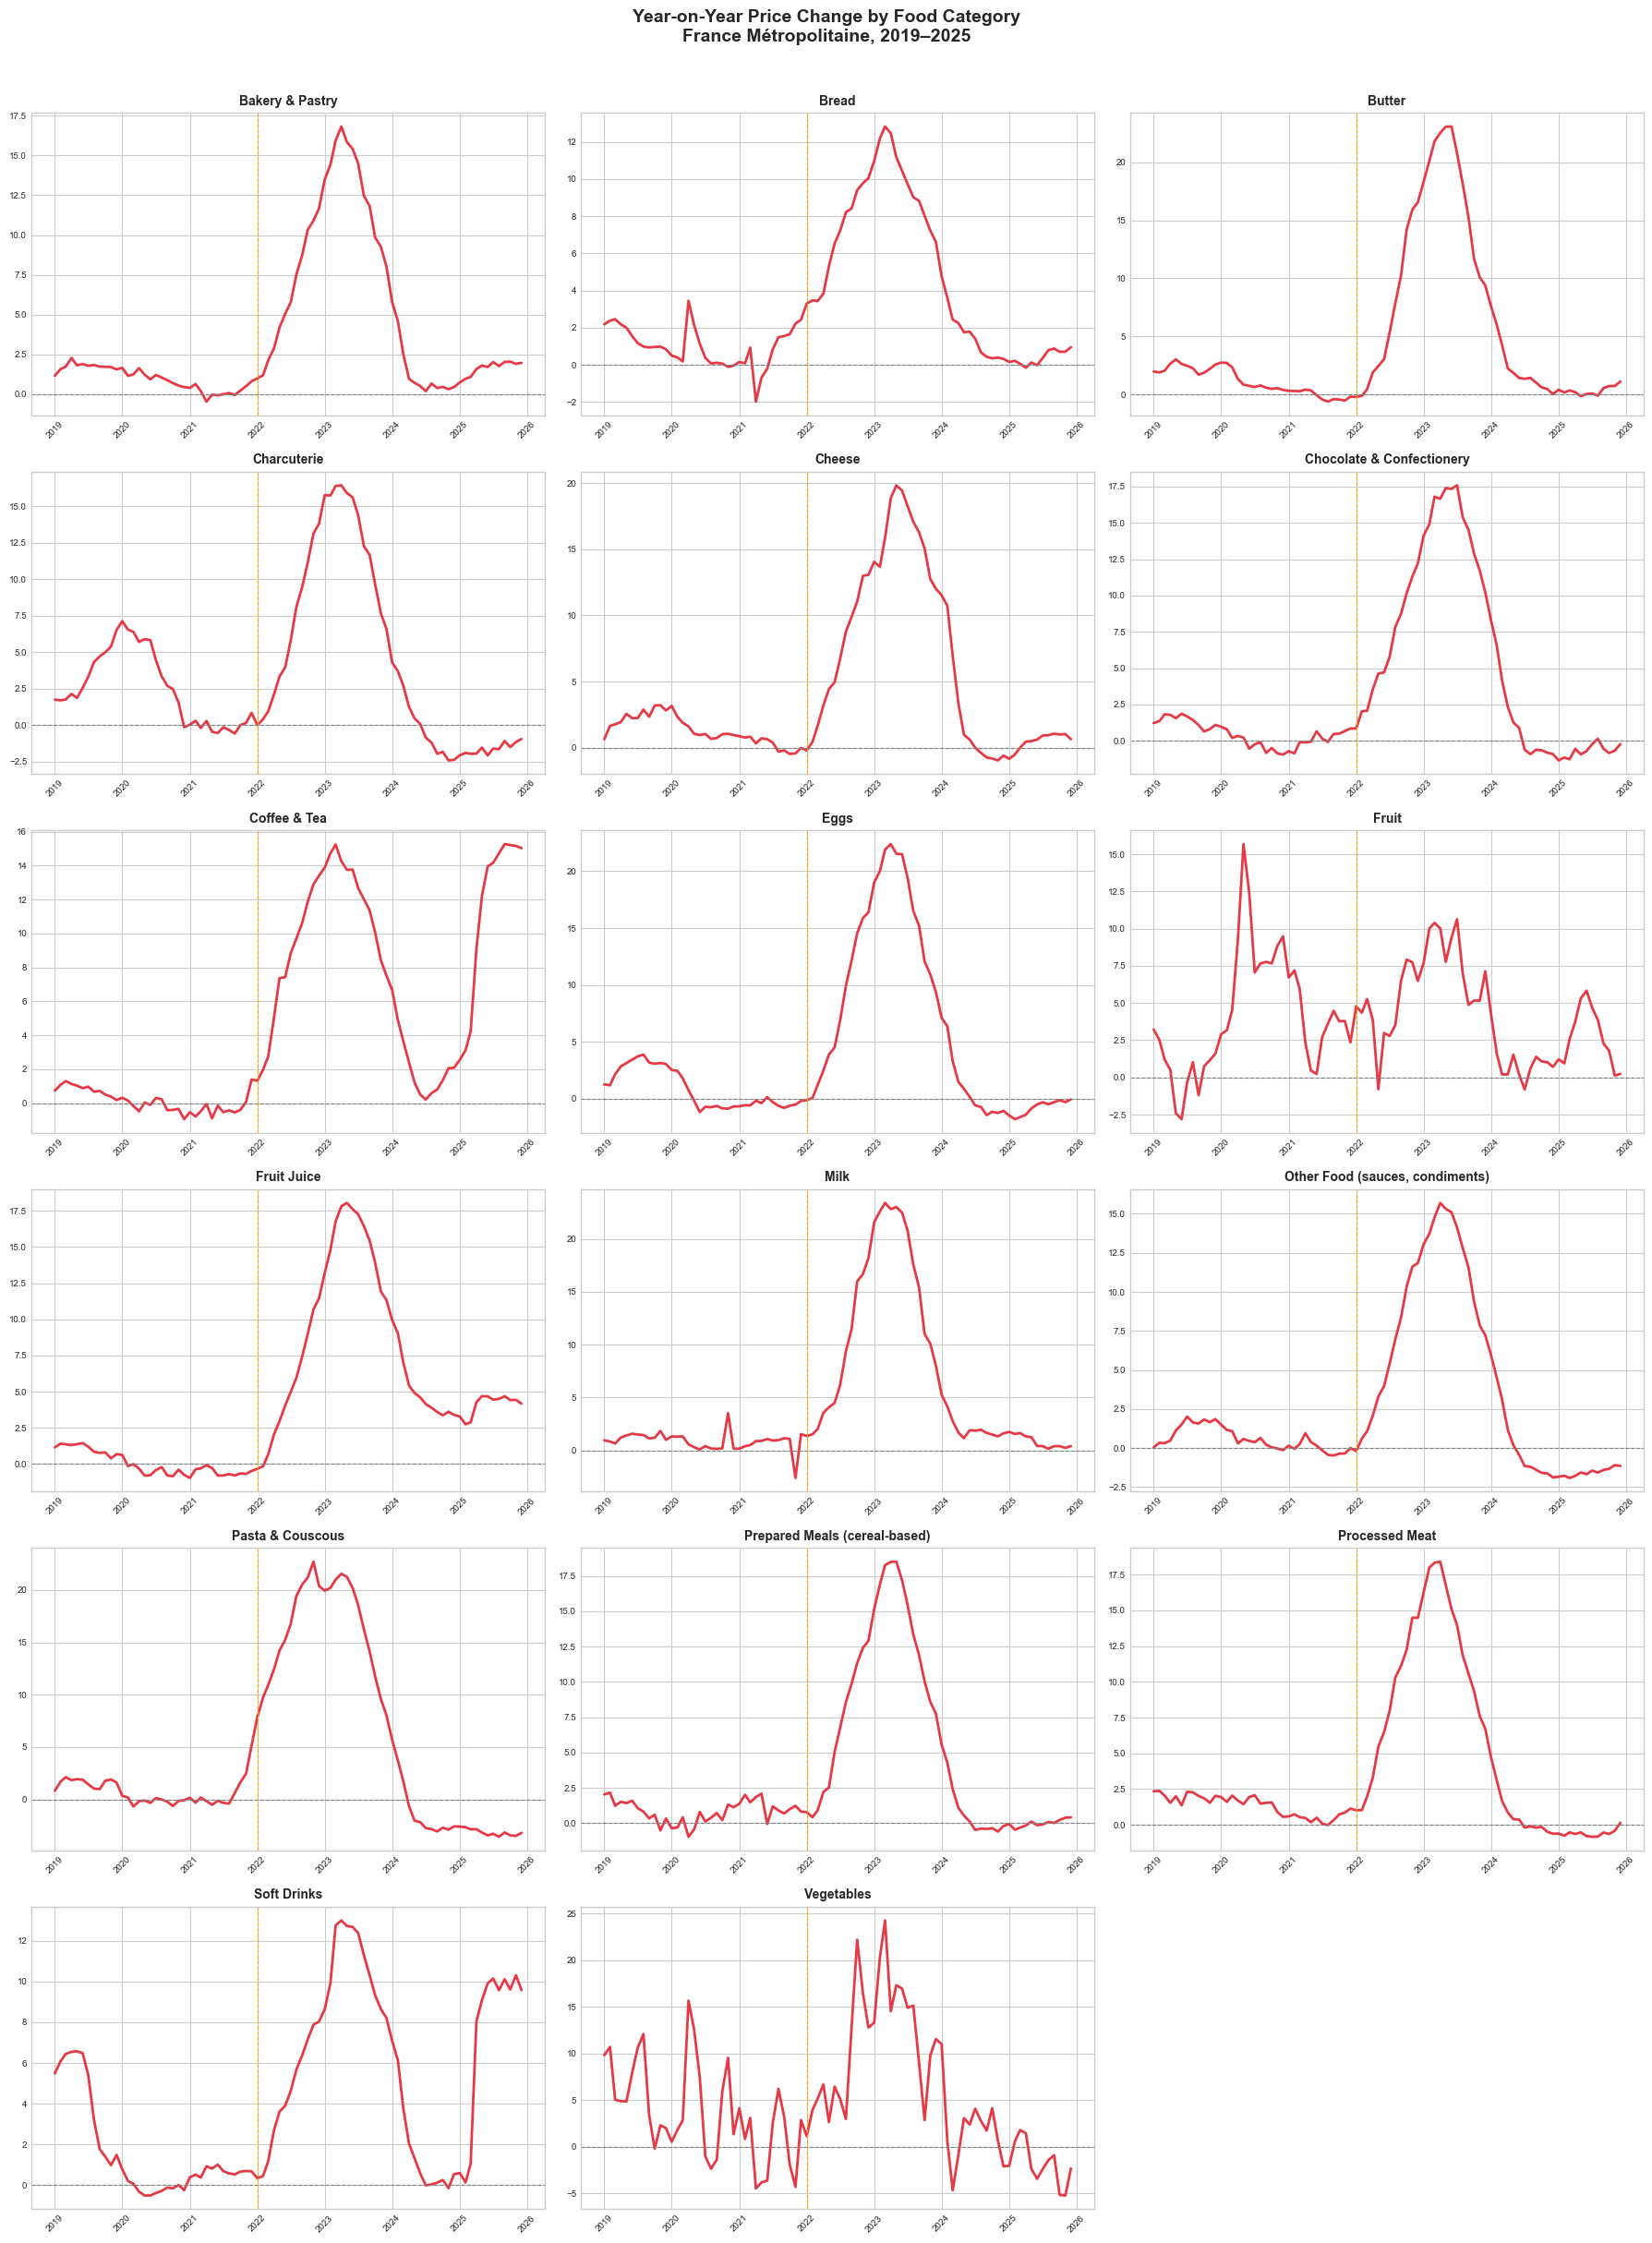

Chart saved to outputs/figures/


In [7]:
# Calculate year-on-year % change per category
insee_long['yoy_change'] = insee_long.groupby('category')['price_index'].pct_change(12) * 100

# Focus on inflation period 2019-2025
plot_data = insee_long[insee_long['date'] >= '2019-01-01'].copy()

# Plot
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

categories = plot_data['category'].unique()

for i, cat in enumerate(sorted(categories)):
    cat_data = plot_data[plot_data['category'] == cat]
    axes[i].plot(cat_data['date'], cat_data['yoy_change'], 
                 color='#e63946', linewidth=2)
    axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].axvline(pd.Timestamp('2022-01-01'), color='orange', 
                    linestyle='--', linewidth=0.8, label='Inflation start')
    axes[i].set_title(cat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle('Year-on-Year Price Change by Food Category\nFrance Métropolitaine, 2019–2025', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/01_inflation_trajectories.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/figures/")

In [8]:
# Compute peak inflation and current inflation per category
summary = insee_long[insee_long['date'] >= '2019-01-01'].copy()
summary['yoy'] = summary.groupby('category')['price_index'].pct_change(12) * 100

peak = summary.groupby('category')['yoy'].max().rename('peak_inflation_pct')
current = summary[summary['date'] >= '2024-06-01'].groupby('category')['yoy'].mean().rename('current_inflation_pct')
price_level = insee_long[insee_long['date'] >= '2024-06-01'].groupby('category')['price_index'].mean().rename('current_index_vs_2015')

shock_table = pd.concat([peak, current, price_level], axis=1).round(2)
shock_table = shock_table.sort_values('peak_inflation_pct', ascending=False)

print("Category Vulnerability from Price Shock:")
print("=" * 65)
print(shock_table.to_string())

Category Vulnerability from Price Shock:
                                 peak_inflation_pct  current_inflation_pct  current_index_vs_2015
category                                                                                         
Vegetables                                    24.26                  -0.40                 145.40
Milk                                          23.40                   1.14                 141.31
Butter                                        23.08                   0.55                 137.53
Pasta & Couscous                              22.71                  -2.98                 130.36
Eggs                                          22.39                  -0.82                 129.19
Cheese                                        19.84                   0.15                 128.50
Prepared Meals (cereal-based)                 18.52                  -0.13                 127.23
Processed Meat                                18.41                  -0.44   

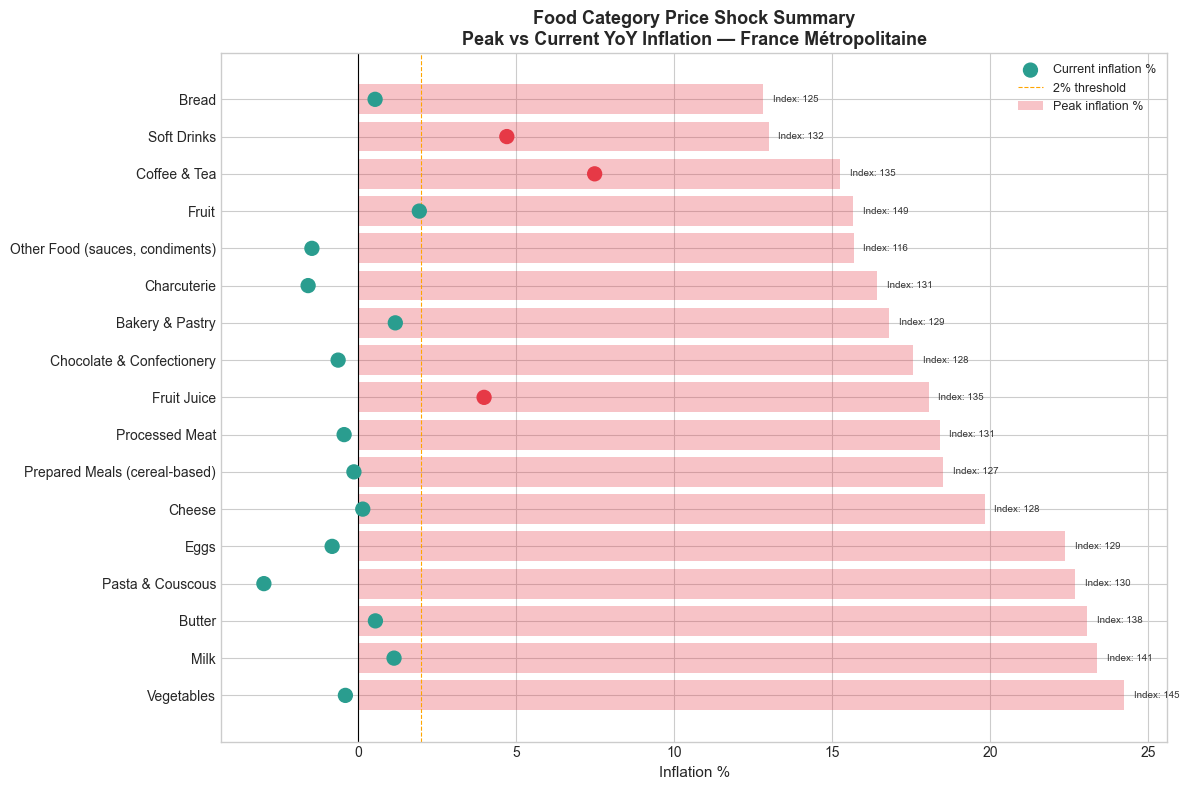

Saved.


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e63946' if x > 2 else '#2a9d8f' 
          for x in shock_table['current_inflation_pct']]

bars = ax.barh(shock_table.index, 
               shock_table['peak_inflation_pct'],
               color='#e63946', alpha=0.3, label='Peak inflation %')

ax.scatter(shock_table['current_inflation_pct'], 
           shock_table.index,
           color=colors, s=100, zorder=5, label='Current inflation %')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=2, color='orange', linewidth=0.8, 
           linestyle='--', label='2% threshold')

for i, (idx, row) in enumerate(shock_table.iterrows()):
    ax.annotate(f"Index: {row['current_index_vs_2015']:.0f}", 
                xy=(row['peak_inflation_pct'], i),
                xytext=(row['peak_inflation_pct'] + 0.3, i),
                fontsize=7, va='center', color='#333333')

ax.set_xlabel('Inflation %', fontsize=11)
ax.set_title('Food Category Price Shock Summary\nPeak vs Current YoY Inflation — France Métropolitaine', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/02_shock_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")